In [3]:
#  Import Libraries
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [4]:
#  Load Cats vs Dogs Dataset from TensorFlow Datasets
# Splitting: 80% train, 20% validation
(ds_train, ds_val), ds_info = tfds.load(
    'cats_vs_dogs',
    split=['train[:80%]', 'train[80%:]'],
    as_supervised=True,  # (image, label)
    with_info=True
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.574YU3_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.


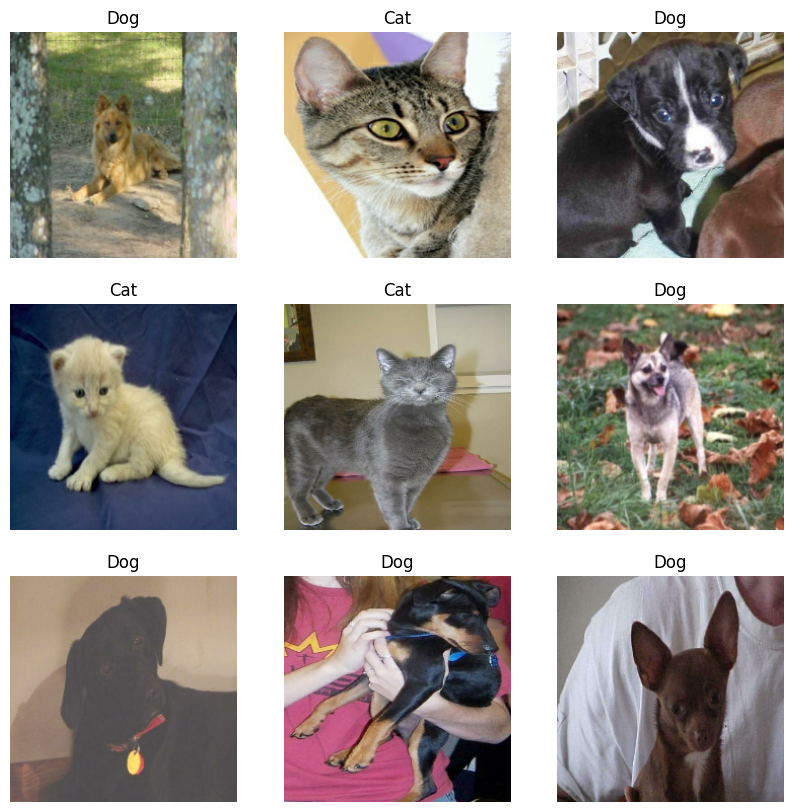

In [7]:
#  Preprocessing and Data Augmentation
IMG_SIZE = 224
BATCH_SIZE = 32

# Preprocessing function
def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = image / 255.0  # Normalize to [0,1]
    return image, label

# Apply preprocessing
train_data = ds_train.map(preprocess).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_data = ds_val.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Optional: Visualize some images
for img, label in train_data.take(1):
    plt.figure(figsize=(10,10))
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(img[i].numpy())
        plt.title("Dog" if label[i]==1 else "Cat")
        plt.axis(False)
    plt.show()

In [8]:
#  Build Advanced Model with Transfer Learning (MobileNetV2)
from tensorflow.keras import layers, models

# Data Augmentation Layer
data_aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])

# Base model
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Freeze base layers

# Complete Model
model = models.Sequential([
    data_aug,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')  # Binary classification
])

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [9]:
#  Compile Model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [10]:
#  Train Model (Initial Training)
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 61s 85ms/step - accuracy: 0.9019 - loss: 0.2314 - val_accuracy: 0.9832 - val_loss: 0.0488
Epoch 2/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 50s 82ms/step - accuracy: 0.9355 - loss: 0.1600 - val_accuracy: 0.9834 - val_loss: 0.0451
Epoch 3/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 50s 83ms/step - accuracy: 0.9396 - loss: 0.1456 - val_accuracy: 0.9847 - val_loss: 0.0431
Epoch 4/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 51s 85ms/step - accuracy: 0.9420 - loss: 0.1437 - val_accuracy: 0.9852 - val_loss: 0.0418
Epoch 5/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 50s 83ms/step - accuracy: 0.9443 - loss: 0.1357 - val_accuracy: 0.9847 - val_loss: 0.0420
Epoch 6/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 50s 83ms/step - accuracy: 0.9470 - loss: 0.1269 - val_accuracy: 0.9858 - val_loss: 0.0407
Epoch 7/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 50s 83ms/step - accuracy: 0.9487 - loss: 0.1256 - val_accuracy: 0.9854 - val_loss: 0.0404
Epoch 8/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 55s 92ms/step - accuracy: 0.9489 - loss: 0.1211 - 

In [11]:
#  Fine-Tuning (Advanced Step)
base_model.trainable = True

# Freeze first layers to avoid overfitting
for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 69s 100ms/step - accuracy: 0.9336 - loss: 0.1631 - val_accuracy: 0.9852 - val_loss: 0.0458
Epoch 2/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 57s 95ms/step - accuracy: 0.9422 - loss: 0.1415 - val_accuracy: 0.9856 - val_loss: 0.0422
Epoch 3/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 58s 97ms/step - accuracy: 0.9472 - loss: 0.1337 - val_accuracy: 0.9850 - val_loss: 0.0424
Epoch 4/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 57s 96ms/step - accuracy: 0.9501 - loss: 0.1223 - val_accuracy: 0.9854 - val_loss: 0.0416
Epoch 5/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 58s 97ms/step - accuracy: 0.9549 - loss: 0.1158 - val_accuracy: 0.9854 - val_loss: 0.0418


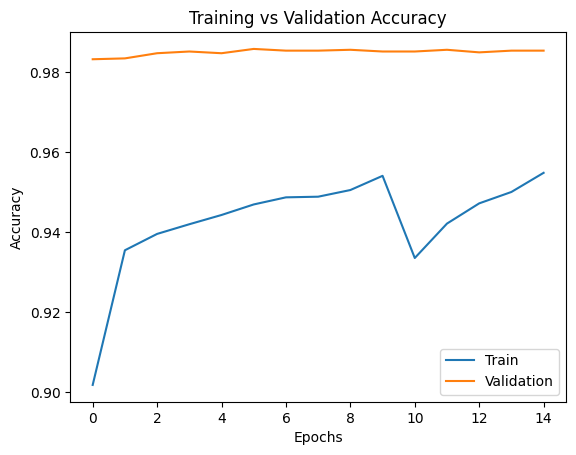

In [12]:
#  Plot Training vs Validation Accuracy
plt.plot(history.history['accuracy'] + history_fine.history['accuracy'])
plt.plot(history.history['val_accuracy'] + history_fine.history['val_accuracy'])
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

In [13]:
#  Save Model for Deployment
model.save("cat_dog_model.h5")

In [15]:
# Simple Test with New Image
from PIL import Image
import numpy as np


from google.colab import files
uploaded = files.upload()

for fn in uploaded.keys():
    img = Image.open(fn).resize((224,224))
    img_array = np.array(img)/255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)
    label = "Dog 🐶" if pred[0][0] > 0.5 else "Cat 🐱"
    print(f"Prediction for {fn}: {label}")

Saving 435688-free-cute-dogs-and-puppies-wallpaper-2560x1600-for-pc.jpg to 435688-free-cute-dogs-and-puppies-wallpaper-2560x1600-for-pc.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
Prediction for 435688-free-cute-dogs-and-puppies-wallpaper-2560x1600-for-pc.jpg: Dog 🐶
